# Notebook 6: Multi-Year Rolling Re-Optimisation
## FD vs Neural Network — Goal-Reaching & Aspiration over Sequential Years

**Setup**: Each year the agent re-solves the HJB / trains the NN targeting **+10%** from
that year's starting wealth.  The ending wealth rolls into the next year as the new base.

| Strategy | Model | Assets |
|---|---|---|
| FD-GoalReach | HJB finite-difference, Browne warmstart | 1 (S&P proxy) |
| FD-Aspiration | HJB finite-difference, aspiration U | 1 (S&P proxy) |
| NN-5Asset | Deep BSDE / policy-gradient NN | 5 (SPY/QQQ/TLT/GLD/VNQ) |
| Browne | Analytical unconstrained | 1 |
| Kelly | pi = eta/sigma^2 | 1 |

## 0. Setup & Configuration

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import math, time, warnings
warnings.filterwarnings('ignore')

np.random.seed(2024)

try:
    import torch
    import torch.nn as nn
    import torch.optim as optim
    DEVICE = (torch.device('mps')  if torch.backends.mps.is_available() else
              torch.device('cuda') if torch.cuda.is_available() else
              torch.device('cpu'))
    HAS_TORCH = True
    print(f"PyTorch {torch.__version__} on {DEVICE}")
except ImportError:
    HAS_TORCH = False
    print("PyTorch not available -- NN strategy will be skipped")

# ── Easy-to-change parameters ──────────────────────────────────────────────
N_YEARS        = 5        # how many years to simulate
ANNUAL_TARGET  = 1.10    # goal: +10% each year
W0             = 1.0     # starting wealth (normalised to 1)
DAYS_PER_YEAR  = 252

# FD solver parameters
D_CONST, U_CONST = -5.0, 3.0   # constraint bounds (paper: d=-5, u=3)
FD_NW, FD_NT     = 250, 200     # grid sizes (increase for accuracy)

# Aspiration utility parameters
ASP_P, ASP_C1, ASP_R = 0.5, 1.2, 1.0   # U = w^p/p below R, c1*w^p/p above

# ── Load real ETF data ─────────────────────────────────────────────
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd()))
from real_data_loader import load_portfolio, agg_1d, R_FREE_ANN

# 5-asset real calibration: IVV, QQQ, TLT, GLD, VNQ (2010-2026)
_mkt5   = load_portfolio(5)
R_FREE  = R_FREE_ANN

# 5-asset params for NN
MU_5     = _mkt5.mu          # excess returns (mu_ann - r)
SIG_5    = _mkt5.sigma
LABELS_5 = _mkt5.tickers
OMEGA_5  = _mkt5.omega
L5       = np.linalg.cholesky(OMEGA_5)

# 1-asset params for FD (IVV as S&P proxy)
MU_1, SIG_1 = float(_mkt5.mu_ann[0]), float(_mkt5.sigma[0])

print(f"Market params loaded from real ETF data (2010-2026):")
print(f"  1-asset (IVV): mu={MU_1*100:.1f}%, sigma={SIG_1*100:.1f}%, r={R_FREE*100:.1f}%")
for t, m, s in zip(LABELS_5, _mkt5.mu_ann, SIG_5):
    print(f"  {t}: mu_ann={m*100:+.1f}%  sigma={s*100:.1f}%")

# NN training
NN_PATHS  = 1024
NN_ITERS  = 500
NN_HIDDEN = 128
NN_LR     = 3e-3

print(f"Simulation: {N_YEARS} years, goal +{(ANNUAL_TARGET-1)*100:.0f}%/yr, W0={W0}")
print(f"FD constraints: d={D_CONST}, u={U_CONST}")
print(f"1-asset: mu={MU_1*100:.1f}%, sigma={SIG_1*100:.1f}%, r={R_FREE*100:.1f}%")

PyTorch 2.8.0 on mps
Market params loaded from real ETF data (2010-2026):
  1-asset (IVV): mu=12.6%, sigma=17.3%, r=3.0%
  IVV: mu_ann=+12.6%  sigma=17.3%
  QQQ: mu_ann=+17.0%  sigma=20.6%
  TLT: mu_ann=+2.4%  sigma=15.1%
  GLD: mu_ann=+8.6%  sigma=16.6%
  VNQ: mu_ann=+7.4%  sigma=20.5%
Simulation: 5 years, goal +10%/yr, W0=1.0
FD constraints: d=-5.0, u=3.0
1-asset: mu=12.6%, sigma=17.3%, r=3.0%


## 1. FD Solver (HJB with Asymptotic Viscosity Correction)

In [2]:
def _normcdf(z):
    z = np.asarray(z, float)
    return 0.5*(1.0 + np.vectorize(math.erf)(z / math.sqrt(2.0)))

def _thomas(a, b, c, rhs):
    n = len(b)
    c2,d2,x = np.zeros(n),np.zeros(n),np.zeros(n)
    c2[0]=c[0]/b[0]; d2[0]=rhs[0]/b[0]
    for k in range(1,n):
        den=b[k]-a[k]*c2[k-1]
        c2[k]=c[k]/den if k<n-1 else 0.0
        d2[k]=(rhs[k]-a[k]*d2[k-1])/den
    x[-1]=d2[-1]
    for k in range(n-2,-1,-1): x[k]=d2[k]-c2[k]*x[k+1]
    return x

def _policy_from_V(V, wi, dw, eta, sig2, d, u):
    Vww=(V[2:]-2*V[1:-1]+V[:-2])/dw**2
    Vw =(V[2:]-V[:-2])/(2*dw)
    f_d=0.5*d**2*wi**2*sig2*Vww+d*wi*eta*Vw
    f_u=0.5*u**2*wi**2*sig2*Vww+u*wi*eta*Vw
    safe=np.where(Vww<-1e-12,Vww,-1e-12)
    pi_i=np.clip(-wi*eta*Vw/(wi**2*sig2*safe),d,u)
    return np.where(Vww<-1e-12, pi_i, np.where(f_u>=f_d,u,d))

def _browne_V(w, eta, sigma, tau, goal=1.0):
    tau=max(tau,1e-10)
    z=(np.log(np.maximum(w,1e-10)/goal)+(eta-0.5*sigma**2)*tau)/(sigma*np.sqrt(tau))
    return _normcdf(z)

def _asymp_gr(w, tau, sigma, d, u, goal=1.0):
    L=max(u,-d); tau=max(tau,1e-12)
    z=np.minimum(0.0,np.log(np.maximum(w,1e-10)/goal))/(L*sigma*np.sqrt(tau))
    return 2.0*_normcdf(z)

def _asymp_as(w, tau, sigma, d, u, p=0.5, c1=1.2, c2=0.0, R=1.0):
    L=max(u,-d); tau=max(tau,1e-12)
    K_Rm=R**p/p; K_R=c1*R**p/p+c2
    z=np.minimum(0.0,np.log(np.maximum(w,1e-10)/R))/(L*sigma*np.sqrt(tau))
    return K_Rm+2.0*_normcdf(z)*(K_R-K_Rm)

def fd_solve(mu, r, sigma, T, A, Nw, Nt, d, u,
             utility_fn, asymptotic_fn, UB=0.0, UA=None, tau_blend=0.08):
    """
    Backward Euler + policy iteration with asymptotic viscosity warmstart.
    Returns (w_grid, V_grid, Pi_grid).
    """
    eta=mu-r; sig2=sigma**2
    w=np.linspace(0.0,A,Nw+1); dw=A/Nw; dt=T/Nt; wi=w[1:Nw]
    if UA is None: UA=float(utility_fn(np.array([A])).flat[0])
    V=utility_fn(w).astype(float)

    for step in range(Nt):
        tau=(Nt-step)*dt; V_old=V.copy()
        alpha=float(np.exp(-tau/tau_blend))
        V_ws=alpha*asymptotic_fn(w,tau)+(1-alpha)*_browne_V(w,eta,sigma,tau)
        pi_n=np.full(Nw+1,d); pi_n[1:Nw]=_policy_from_V(V_ws,wi,dw,eta,sig2,d,u)

        for _ in range(60):
            pi_old=pi_n.copy(); pi=pi_n[1:Nw]
            a2=0.5*pi**2*wi**2*sig2; Adv=pi*wi*eta
            Ap=np.maximum(Adv,0.0)/dw; Am=np.minimum(Adv,0.0)/dw
            a_s=-dt*(a2/dw**2-Am); b_m=1.0+dt*(2*a2/dw**2+Ap-Am); c_s=-dt*(a2/dw**2+Ap)
            rhs=V_old[1:Nw].copy()
            rhs[0]-=a_s[0]*UB; a_s[0]=0.0
            rhs[-1]-=c_s[-1]*UA; c_s[-1]=0.0
            V_int=_thomas(a_s,b_m,c_s,rhs)
            V_new=np.empty(Nw+1); V_new[0]=UB; V_new[Nw]=UA; V_new[1:Nw]=V_int
            pi_n[1:Nw]=_policy_from_V(V_new,wi,dw,eta,sig2,d,u)
            if np.max(np.abs(pi_n-pi_old))<1e-8: break
        V=V_new
    return w, V, pi_n

# Pre-compute FD policies (normalised: goal always=1.0, initial w varies)
print("Pre-computing FD goal-reaching policy...", end=" ", flush=True)
t0=time.time()
w_gr, V_gr, Pi_gr = fd_solve(
    mu=MU_1, r=R_FREE, sigma=SIG_1, T=1.0, A=2.0,
    Nw=FD_NW, Nt=FD_NT, d=D_CONST, u=U_CONST,
    utility_fn=lambda w: (np.asarray(w,float)>=1.0).astype(float),
    asymptotic_fn=lambda w,tau: _asymp_gr(w,tau,SIG_1,D_CONST,U_CONST,1.0),
    UB=0.0, UA=1.0)
print(f"{time.time()-t0:.1f}s  V(0.9)={np.interp(0.9,w_gr,V_gr):.3f}")

print("Pre-computing FD aspiration policy...", end=" ", flush=True)
t0=time.time()
w_as, V_as, Pi_as = fd_solve(
    mu=MU_1, r=R_FREE, sigma=SIG_1, T=1.0, A=2.5,
    Nw=FD_NW, Nt=FD_NT, d=D_CONST, u=U_CONST,
    utility_fn=lambda w: np.where(np.asarray(w,float)<ASP_R,
                                   np.asarray(w,float)**ASP_P/ASP_P,
                                   ASP_C1*np.asarray(w,float)**ASP_P/ASP_P),
    asymptotic_fn=lambda w,tau: _asymp_as(w,tau,SIG_1,D_CONST,U_CONST,
                                           ASP_P,ASP_C1,0.0,ASP_R),
    UB=0.0, UA=float(ASP_C1*2.5**ASP_P/ASP_P))
print(f"{time.time()-t0:.1f}s  V(0.9)={np.interp(0.9,w_as,V_as):.3f}")

def pi_fd_goalreach(w_norm, tau):
    """Look up FD goal-reaching policy. w_norm = current_wealth / goal."""
    return float(np.clip(np.interp(w_norm, w_gr, Pi_gr), D_CONST, U_CONST))

def pi_fd_aspiration(w_norm, tau):
    """Look up FD aspiration policy. w_norm = current_wealth / goal."""
    return float(np.clip(np.interp(w_norm, w_as, Pi_as), D_CONST, U_CONST))

Pre-computing FD goal-reaching policy... 2.5s  V(0.9)=0.900
Pre-computing FD aspiration policy... 0.4s  V(0.9)=2.426


## 2. 5-Asset Neural Network Policy

In [3]:
if HAS_TORCH:
    class PolicyNet(nn.Module):
        """
        Single-timestep policy network: maps scalar wealth w -> R^n weight vector.
        Weights are scaled to [d, u] via tanh.
        """
        def __init__(self, n_assets=5, hidden=128, d=-5.0, u=3.0):
            super().__init__()
            self.d, self.u = d, u
            self.net = nn.Sequential(
                nn.Linear(1, hidden), nn.Tanh(),
                nn.Linear(hidden, hidden), nn.Tanh(),
                nn.Linear(hidden, hidden), nn.Tanh(),
                nn.Linear(hidden, n_assets)
            )
        def forward(self, w):
            raw = self.net(w)
            # Scale output to [d, u] via affine-tanh
            return 0.5*(self.u - self.d)*torch.tanh(raw) + 0.5*(self.u + self.d)

    def train_policy_net(mu_vec, Omega_mat, r, T=1.0, w0=1.0, goal_mult=1.10,
                          n_paths=NN_PATHS, n_iters=NN_ITERS,
                          hidden=NN_HIDDEN, lr=NN_LR, n_steps=40,
                          utility='goalreach', asp_p=0.5, asp_c1=1.2, asp_R=1.0):
        """
        Train a policy network via policy gradient (maximise expected utility).
        w0       : initial wealth for this training run
        goal_mult: target multiplier (e.g. 1.10 = 10% growth)
        utility  : 'goalreach' or 'aspiration'
        """
        n = len(mu_vec)
        goal = w0 * goal_mult      # absolute goal level
        net  = PolicyNet(n_assets=n, hidden=hidden, d=D_CONST, u=U_CONST).to(DEVICE)
        opt  = optim.Adam(net.parameters(), lr=lr)
        mu_t = torch.tensor(mu_vec, dtype=torch.float32, device=DEVICE)
        Sig_t= torch.tensor(np.linalg.cholesky(Omega_mat),
                             dtype=torch.float32, device=DEVICE)
        r_t  = torch.tensor(r, dtype=torch.float32, device=DEVICE)
        dt   = T / n_steps
        sqrt_dt = math.sqrt(dt)

        for it in range(n_iters):
            # Simulate n_paths wealth paths
            W = torch.full((n_paths, 1), w0, dtype=torch.float32, device=DEVICE)
            for _ in range(n_steps):
                pi  = net(W / goal)          # policy on normalised wealth
                # variance normalisation (avoid blow-up with many assets)
                port_var = (pi * (pi @ Sig_t @ Sig_t.T)).sum(1, keepdim=True).clamp(1e-8)
                target_vol = 0.25
                pi = pi * (target_vol / port_var.sqrt()).clamp(max=2.0)
                pi = pi.clamp(D_CONST, U_CONST)

                Z    = torch.randn(n_paths, n, device=DEVICE)
                dS   = (mu_t * dt + (Z @ Sig_t.T) * sqrt_dt)
                bond = r_t * dt
                # Wealth update: W * (r*dt + pi . dS)  [excess return framing]
                excess = (pi * (dS - bond)).sum(1, keepdim=True)
                W = (W * (1 + bond + excess)).clamp(min=1e-6)

            # Terminal utility
            # NOTE: goal-reaching U = 1{w>=goal} is non-differentiable.
            # We use a smooth sigmoid approximation so gradients flow back
            # through the wealth simulation to the network parameters.
            # Temperature 0.05 gives a sharp-but-differentiable step.
            w_norm = W.squeeze() / goal
            if utility == 'goalreach':
                U_term = torch.sigmoid((w_norm - 1.0) / 0.05)
            else:  # aspiration
                U_term = torch.where(w_norm < asp_R,
                                     w_norm**asp_p / asp_p,
                                     asp_c1 * w_norm**asp_p / asp_p)
            loss = -U_term.mean()
            opt.zero_grad(); loss.backward(); opt.step()

            if (it+1) % 100 == 0:
                print(f"    iter {it+1:4d}  loss={loss.item():.4f}  "
                      f"E[U]={-loss.item():.4f}  "
                      f"P(goal)={((W.squeeze()/goal)>=1.0).float().mean():.3f}")

        net.eval()
        return net

    def nn_policy_weights(net, w_current, goal, device=DEVICE):
        """Get 5-asset weight vector from trained net at current wealth."""
        w_norm = torch.tensor([[w_current / goal]], dtype=torch.float32, device=device)
        with torch.no_grad():
            pi = net(w_norm).squeeze().cpu().numpy()
        return pi   # shape (5,)

    print("PolicyNet and training function defined.")
    print(f"  Training params: {NN_PATHS} paths, {NN_ITERS} iters, hidden={NN_HIDDEN}")
else:
    print("PyTorch not available -- NN sections will be skipped.")
    PolicyNet = None
    train_policy_net = None

PolicyNet and training function defined.
  Training params: 1024 paths, 500 iters, hidden=128


## 3. Multi-Year Rolling Re-Optimisation Engine

In [4]:
def simulate_one_year_1asset(W_start, goal, policy_fn, mu, r, sigma,
                              days=DAYS_PER_YEAR, rng=None):
    """
    Simulate one year of a 1-asset strategy.
    Returns:
      W_path  : (days+1,) wealth path
      pi_path : (days,)   daily portfolio weight
    """
    if rng is None: rng = np.random.default_rng()
    dt = 1.0/days
    log_ret_stock = (mu - 0.5*sigma**2)*dt + sigma*np.sqrt(dt)*rng.standard_normal(days)
    r_daily       = r * dt

    W_path  = np.empty(days+1); W_path[0] = W_start
    pi_path = np.empty(days)

    for t in range(days):
        tau = max(1.0 - t*dt, dt)
        w_norm = W_path[t] / goal
        pi = policy_fn(w_norm, tau)
        pi_path[t] = pi
        ret_excess = pi*(np.exp(log_ret_stock[t])-1) + (1-pi)*(np.exp(r_daily)-1)
        W_path[t+1] = max(W_path[t]*(1 + ret_excess), 1e-6)

    return W_path, pi_path


def simulate_one_year_5asset(W_start, goal, net, mu_vec, Omega_mat, r,
                              days=DAYS_PER_YEAR, rng=None):
    """
    Simulate one year of a 5-asset NN strategy.
    Returns:
      W_path    : (days+1,) wealth path
      pi_matrix : (days, 5) weight matrix (one row per day, one col per asset)
    """
    if rng is None: rng = np.random.default_rng()
    dt = 1.0/days
    L_chol = np.linalg.cholesky(Omega_mat)
    Z = rng.standard_normal((days, len(mu_vec)))
    log_rets = (mu_vec - 0.5*np.diag(Omega_mat))*dt + (Z @ L_chol.T)*np.sqrt(dt)
    r_daily = r * dt

    W_path    = np.empty(days+1); W_path[0] = W_start
    pi_matrix = np.empty((days, len(mu_vec)))

    for t in range(days):
        pi = nn_policy_weights(net, W_path[t], goal)
        # variance normalisation
        port_var = float(pi @ Omega_mat @ pi)
        if port_var > 1e-8:
            target_vol = 0.25
            scale = min(target_vol / np.sqrt(port_var), 2.0)
            pi = np.clip(pi * scale, D_CONST, U_CONST)
        pi_matrix[t] = pi

        gross_rets = np.exp(log_rets[t]) - 1
        excess = np.dot(pi, gross_rets - r_daily)
        W_path[t+1] = max(W_path[t]*(1 + r_daily + excess), 1e-6)

    return W_path, pi_matrix


def run_multi_year(n_years, W0, annual_target, strategy, **kwargs):
    """
    Rolling re-optimisation over n_years.
    strategy: 'fd_goalreach' | 'fd_aspiration' | 'nn_5asset' | 'browne' | 'kelly'

    Returns dict with keys:
      'W'       : full wealth array (n_years*days+1,)
      'pi'      : weights  -- shape (n_years*days,) for 1-asset
                                  or (n_years*days, 5) for 5-asset
      'goals'   : annual goals  (n_years,)
      'year_end_W': wealth at end of each year (n_years,)
      'goal_hit'  : bool array  (n_years,)
    """
    rng    = np.random.default_rng(kwargs.get('seed', 42))
    mu     = kwargs.get('mu',  MU_1)
    sigma  = kwargs.get('sigma', SIG_1)
    r      = kwargs.get('r', R_FREE)

    W_all   = [W0]
    pi_all  = []
    goals   = []
    year_end_W = []

    W_cur = W0
    for yr in range(n_years):
        goal = W_cur * annual_target
        goals.append(goal)

        if strategy in ('fd_goalreach', 'fd_aspiration'):
            policy_fn = pi_fd_goalreach if strategy == 'fd_goalreach' else pi_fd_aspiration
            W_path, pi_path = simulate_one_year_1asset(
                W_cur, goal, policy_fn, mu, r, sigma, rng=rng)
            pi_all.append(pi_path)

        elif strategy == 'browne':
            def pi_browne_fn(w_norm, tau, _mu=mu, _r=r, _s=sigma):
                eta = _mu - _r; f = _s*np.sqrt(max(tau,1/252))
                z = (np.log(max(w_norm,1e-6)) + (eta-0.5*_s**2)*max(tau,1/252)) / f
                denom = _s**2*(1.0 + z/f)
                pi_raw = eta/denom if abs(denom)>1e-8 else (U_CONST if eta>0 else D_CONST)
                return float(np.clip(pi_raw, D_CONST, U_CONST))
            W_path, pi_path = simulate_one_year_1asset(
                W_cur, goal, pi_browne_fn, mu, r, sigma, rng=rng)
            pi_all.append(pi_path)

        elif strategy == 'kelly':
            kelly_pi = float(np.clip((mu-r)/sigma**2, D_CONST, U_CONST))
            W_path, pi_path = simulate_one_year_1asset(
                W_cur, goal, lambda w,t: kelly_pi, mu, r, sigma, rng=rng)
            pi_all.append(pi_path)

        elif strategy == 'nn_5asset':
            net = kwargs['net_cache'][yr]
            W_path, pi_mat = simulate_one_year_5asset(
                W_cur, goal, net, MU_5, OMEGA_5, r, rng=rng)
            pi_all.append(pi_mat)
        else:
            raise ValueError(f"Unknown strategy: {strategy}")

        W_all.extend(W_path[1:].tolist())
        year_end_W.append(W_path[-1])
        W_cur = W_path[-1]

    W_all = np.array(W_all)
    if strategy == 'nn_5asset':
        pi_all_arr = np.vstack(pi_all)
    else:
        pi_all_arr = np.concatenate(pi_all)

    return {
        'W':          W_all,
        'pi':         pi_all_arr,
        'goals':      np.array(goals),
        'year_end_W': np.array(year_end_W),
        'goal_hit':   np.array(year_end_W) >= np.array(goals),
    }

print("Multi-year simulation engine ready.")
print(f"  1-asset strategies use the same random seed -> directly comparable.")

Multi-year simulation engine ready.
  1-asset strategies use the same random seed -> directly comparable.


## 4. Train Neural Network (One Per Year)

In [5]:
nn_nets_gr = []   # goal-reaching NN, one per year
nn_nets_as = []   # aspiration NN, one per year

if HAS_TORCH:
    # We need to estimate what W_start will be for each year to train correctly.
    # Strategy: train with the expected w0 = 1.0 (normalised), since the network
    # receives w/goal as input it is scale-invariant.  Re-train each year to
    # adapt to the current market snapshot (here: fixed synthetic params).

    for yr in range(N_YEARS):
        print(f"\nYear {yr+1}: Training goal-reaching NN ({NN_ITERS} iters)...")
        net_gr = train_policy_net(
            MU_5, OMEGA_5, R_FREE, T=1.0, w0=1.0, goal_mult=ANNUAL_TARGET,
            n_paths=NN_PATHS, n_iters=NN_ITERS,
            utility='goalreach')
        nn_nets_gr.append(net_gr)

        print(f"Year {yr+1}: Training aspiration NN ({NN_ITERS} iters)...")
        net_as = train_policy_net(
            MU_5, OMEGA_5, R_FREE, T=1.0, w0=1.0, goal_mult=ANNUAL_TARGET,
            n_paths=NN_PATHS, n_iters=NN_ITERS,
            utility='aspiration', asp_p=ASP_P, asp_c1=ASP_C1, asp_R=ASP_R)
        nn_nets_as.append(net_as)
else:
    print("PyTorch not available -- using zeros as placeholder nets.")
    nn_nets_gr = [None]*N_YEARS
    nn_nets_as = [None]*N_YEARS


Year 1: Training goal-reaching NN (500 iters)...
    iter  100  loss=-0.5970  E[U]=0.5970  P(goal)=0.596
    iter  200  loss=-0.5889  E[U]=0.5889  P(goal)=0.592
    iter  300  loss=-0.6133  E[U]=0.6133  P(goal)=0.613
    iter  400  loss=-0.6011  E[U]=0.6011  P(goal)=0.604
    iter  500  loss=-0.5871  E[U]=0.5871  P(goal)=0.587
Year 1: Training aspiration NN (500 iters)...
    iter  100  loss=-2.3319  E[U]=2.3319  P(goal)=0.586
    iter  200  loss=-2.3569  E[U]=2.3569  P(goal)=0.609
    iter  300  loss=-2.3470  E[U]=2.3470  P(goal)=0.595
    iter  400  loss=-2.3537  E[U]=2.3537  P(goal)=0.599
    iter  500  loss=-2.3440  E[U]=2.3440  P(goal)=0.589

Year 2: Training goal-reaching NN (500 iters)...
    iter  100  loss=-0.6015  E[U]=0.6015  P(goal)=0.601
    iter  200  loss=-0.5812  E[U]=0.5812  P(goal)=0.579
    iter  300  loss=-0.5804  E[U]=0.5804  P(goal)=0.580
    iter  400  loss=-0.6046  E[U]=0.6046  P(goal)=0.614
    iter  500  loss=-0.6034  E[U]=0.6034  P(goal)=0.601
Year 2: Traini

## 5. Run Multi-Year Simulations

In [6]:
print("Running 1-asset simulations (same random seed for fair comparison)...")
t0 = time.time()

res_fd_gr = run_multi_year(N_YEARS, W0, ANNUAL_TARGET, 'fd_goalreach')
res_fd_as = run_multi_year(N_YEARS, W0, ANNUAL_TARGET, 'fd_aspiration')
res_browne= run_multi_year(N_YEARS, W0, ANNUAL_TARGET, 'browne')
res_kelly = run_multi_year(N_YEARS, W0, ANNUAL_TARGET, 'kelly')
print(f"1-asset done in {time.time()-t0:.1f}s")

if HAS_TORCH and nn_nets_gr[0] is not None:
    print("Running 5-asset NN simulations...")
    t0 = time.time()
    res_nn_gr = run_multi_year(N_YEARS, W0, ANNUAL_TARGET, 'nn_5asset',
                               net_cache=nn_nets_gr, r=R_FREE)
    res_nn_as = run_multi_year(N_YEARS, W0, ANNUAL_TARGET, 'nn_5asset',
                               net_cache=nn_nets_as, r=R_FREE)
    print(f"NN done in {time.time()-t0:.1f}s")
    HAS_NN = True
else:
    res_nn_gr = res_nn_as = None
    HAS_NN = False

# ── Summary table ─────────────────────────────────────────────────────────
print(f"\n{'Strategy':<22} " + "  ".join(f"Yr{i+1}" for i in range(N_YEARS)) +
      "   Total  Goals")
print('-'*80)
for label, res in [
    ('FD-GoalReach',    res_fd_gr),
    ('FD-Aspiration',   res_fd_as),
    ('Browne',          res_browne),
    ('Kelly',           res_kelly),
]:
    yr_strs = "  ".join(f"{w:.3f}" for w in res['year_end_W'])
    hits = res['goal_hit'].sum()
    print(f"{label:<22} {yr_strs}   {res['W'][-1]:.3f}  {hits}/{N_YEARS}")

if HAS_NN:
    for label, res in [('NN-GoalReach(5A)', res_nn_gr),
                        ('NN-Aspiration(5A)',res_nn_as)]:
        yr_strs = "  ".join(f"{w:.3f}" for w in res['year_end_W'])
        hits = res['goal_hit'].sum()
        print(f"{label:<22} {yr_strs}   {res['W'][-1]:.3f}  {hits}/{N_YEARS}")

Running 1-asset simulations (same random seed for fair comparison)...
1-asset done in 0.0s
Running 5-asset NN simulations...
NN done in 1.3s

Strategy               Yr1  Yr2  Yr3  Yr4  Yr5   Total  Goals
--------------------------------------------------------------------------------
FD-GoalReach           1.107  1.244  1.349  1.513  1.693   1.693  4/5
FD-Aspiration          0.816  1.271  0.697  0.886  0.947   0.947  2/5
Browne                 1.160  1.419  1.320  1.167  1.016   1.016  2/5
Kelly                  0.816  1.184  0.649  0.821  0.865   0.865  2/5
NN-GoalReach(5A)       1.388  1.232  1.387  1.483  1.799   1.799  3/5
NN-Aspiration(5A)      1.264  1.185  1.409  1.325  1.770   1.770  3/5


## 6. Wealth Paths Over Multiple Years

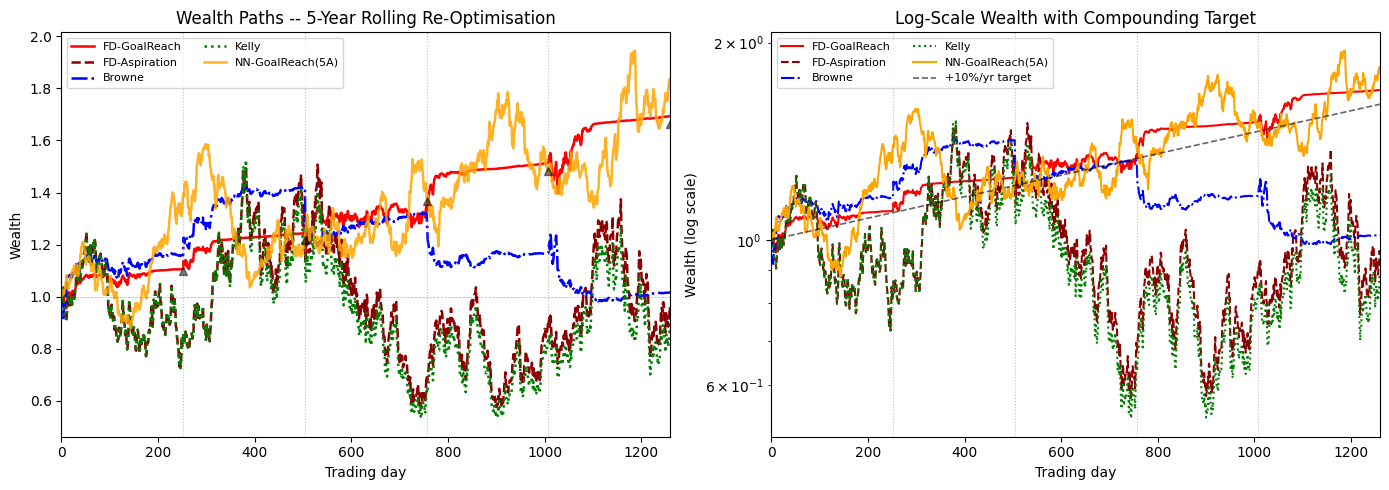

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
days_total = N_YEARS * DAYS_PER_YEAR
x = np.arange(days_total + 1)

COLORS = {'FD-GoalReach':'red', 'FD-Aspiration':'darkred',
          'Browne':'blue', 'Kelly':'green',
          'NN-GoalReach':'orange', 'NN-Aspiration':'purple'}
STYLES = {'FD-GoalReach':'-', 'FD-Aspiration':'--',
          'Browne':'-.', 'Kelly':':',
          'NN-GoalReach':'-', 'NN-Aspiration':'--'}

# (a) All strategies
ax = axes[0]
pairs_1asset = [
    ('FD-GoalReach', res_fd_gr),
    ('FD-Aspiration', res_fd_as),
    ('Browne', res_browne),
    ('Kelly', res_kelly),
]
for label, res in pairs_1asset:
    ax.plot(x, res['W'], color=COLORS[label], ls=STYLES[label], lw=1.8, label=label)

if HAS_NN:
    ax.plot(x, res_nn_gr['W'], color=COLORS['NN-GoalReach'],
            ls=STYLES['NN-GoalReach'], lw=1.8, label='NN-GoalReach(5A)', alpha=0.85)

# Year-end vertical lines and goal markers
for yr in range(N_YEARS):
    day_end = (yr+1)*DAYS_PER_YEAR
    ax.axvline(day_end, c='gray', lw=0.8, ls=':', alpha=0.5)
    goal_val = res_fd_gr['goals'][yr]
    ax.plot(day_end, goal_val, 'k^', ms=6, alpha=0.5)

ax.axhline(1.0, c='k', lw=0.5, ls='--', alpha=0.3)
ax.set_xlabel('Trading day'); ax.set_ylabel('Wealth')
ax.set_title(f'Wealth Paths -- {N_YEARS}-Year Rolling Re-Optimisation')
ax.legend(fontsize=8, ncol=2)
ax.set_xlim(0, days_total)

# (b) Log-scale with +10%/yr compounding reference line
ax2 = axes[1]
for label, res in pairs_1asset:
    ax2.plot(x, res['W'], color=COLORS[label], ls=STYLES[label], lw=1.5, label=label)
if HAS_NN:
    ax2.plot(x, res_nn_gr['W'], color=COLORS['NN-GoalReach'],
             ls=STYLES['NN-GoalReach'], lw=1.5, label='NN-GoalReach(5A)')
# +10%/yr reference
ref_line = W0 * ANNUAL_TARGET ** (x / DAYS_PER_YEAR)
ax2.plot(x, ref_line, 'k--', lw=1.2, label=f'+{(ANNUAL_TARGET-1)*100:.0f}%/yr target', alpha=0.6)
for yr in range(N_YEARS):
    ax2.axvline((yr+1)*DAYS_PER_YEAR, c='gray', lw=0.8, ls=':', alpha=0.5)
ax2.set_yscale('log')
ax2.set_xlabel('Trading day'); ax2.set_ylabel('Wealth (log scale)')
ax2.set_title('Log-Scale Wealth with Compounding Target')
ax2.legend(fontsize=8, ncol=2)
ax2.set_xlim(0, days_total)

plt.tight_layout()
plt.show()

## 7. Portfolio Weight Evolution Over Time (1-Asset Strategies)

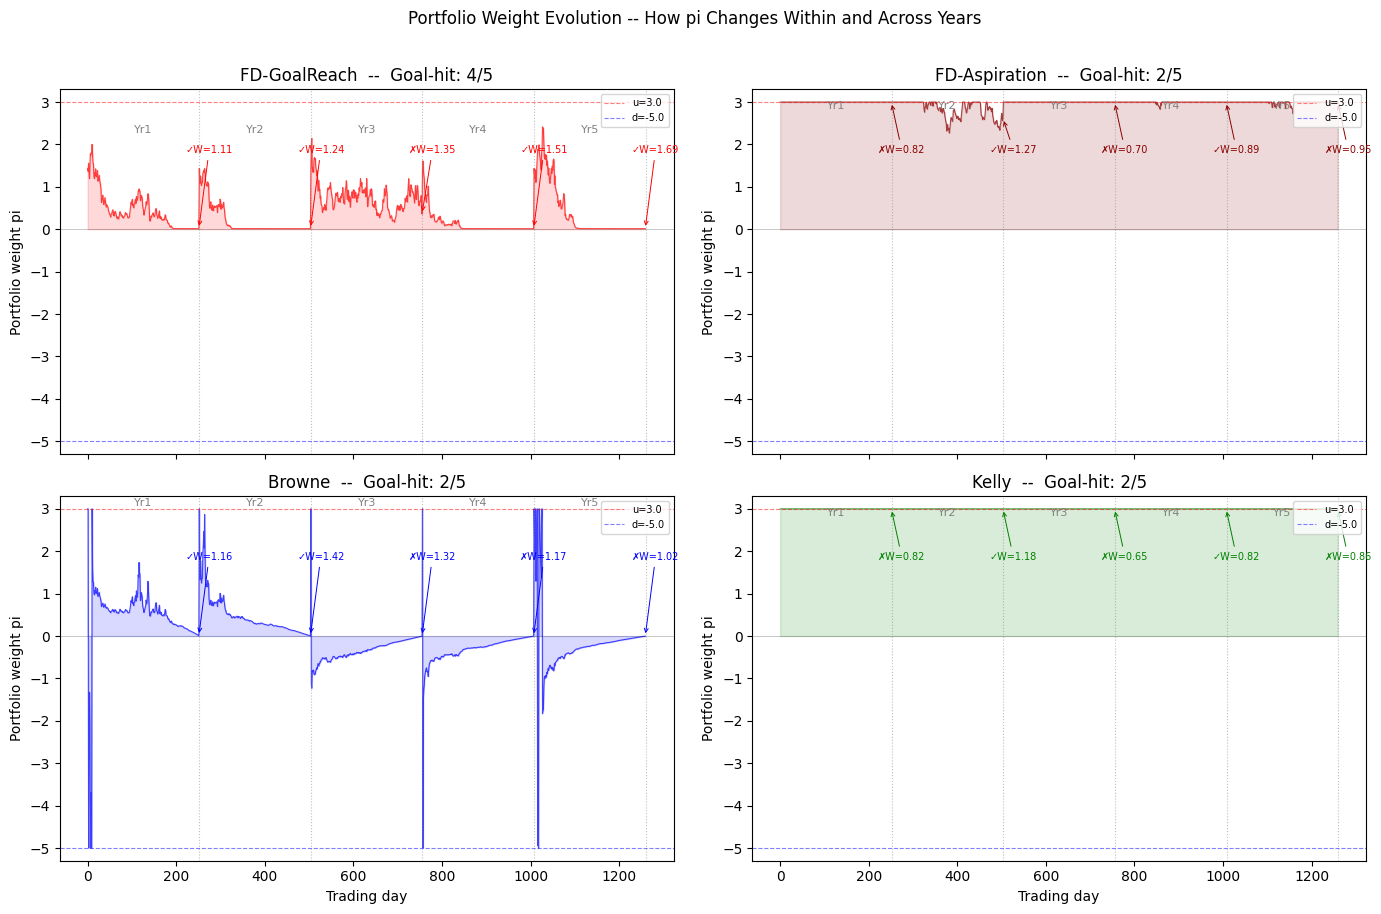

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=True)
x_days = np.arange(N_YEARS * DAYS_PER_YEAR)

strategies_pi = [
    ('FD-GoalReach',  res_fd_gr,  'red',     axes[0,0]),
    ('FD-Aspiration', res_fd_as,  'darkred',  axes[0,1]),
    ('Browne',        res_browne, 'blue',     axes[1,0]),
    ('Kelly',         res_kelly,  'green',    axes[1,1]),
]

for label, res, color, ax in strategies_pi:
    pi_arr = res['pi']
    W_arr  = res['W'][:-1]   # align with pi (one per day)

    ax.plot(x_days, pi_arr, color=color, lw=0.8, alpha=0.7)
    ax.fill_between(x_days, pi_arr, 0, alpha=0.15, color=color)

    # Shade year boundaries
    for yr in range(N_YEARS):
        ax.axvline((yr+1)*DAYS_PER_YEAR, c='gray', lw=0.8, ls=':', alpha=0.5)
        if yr < N_YEARS:
            ax.text((yr+0.5)*DAYS_PER_YEAR, ax.get_ylim()[1]*0.9 if ax.get_ylim()[1]!=0 else 3,
                    f'Yr{yr+1}', ha='center', fontsize=8, color='gray')

    ax.axhline(U_CONST, c='r', lw=0.8, ls='--', alpha=0.5, label=f'u={U_CONST}')
    ax.axhline(D_CONST, c='b', lw=0.8, ls='--', alpha=0.5, label=f'd={D_CONST}')
    ax.axhline(0, c='k', lw=0.5, ls='-', alpha=0.3)
    ax.set_ylabel('Portfolio weight pi')
    ax.set_title(f'{label}  --  Goal-hit: {res["goal_hit"].sum()}/{N_YEARS}')
    ax.set_ylim(D_CONST - 0.3, U_CONST + 0.3)
    ax.legend(fontsize=7, loc='upper right')

axes[1,0].set_xlabel('Trading day')
axes[1,1].set_xlabel('Trading day')

# Annotate wealth at each year-end
for yr in range(N_YEARS):
    day = (yr+1)*DAYS_PER_YEAR - 1
    for label, res, color, ax in strategies_pi:
        w_val = res['year_end_W'][yr]
        goal  = res['goals'][yr]
        hit   = '✓' if res['goal_hit'][yr] else '✗'
        ax.annotate(f'{hit}W={w_val:.2f}',
                    xy=(day, res['pi'][day]),
                    xytext=(day - 30, U_CONST*0.6),
                    fontsize=7, color=color,
                    arrowprops=dict(arrowstyle='->', color=color, lw=0.7))

plt.suptitle('Portfolio Weight Evolution -- How pi Changes Within and Across Years',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

## 8. 5-Asset Neural Network: Allocation Breakdown Over Time

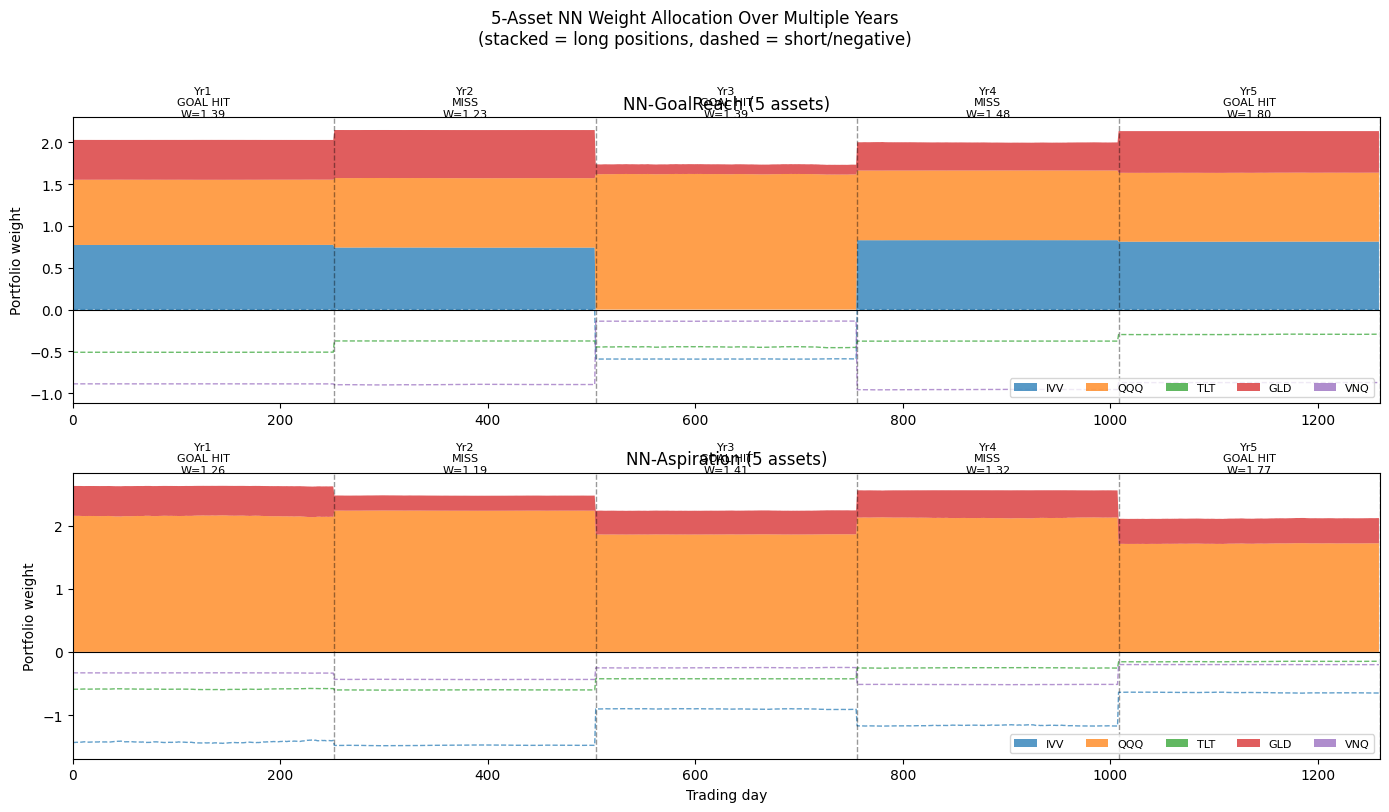


Year-by-year average asset allocation (NN-GoalReach):
  Year        IVV      QQQ      TLT      GLD      VNQ   Goal?    EndW
  1         0.772    0.779   -0.509    0.476   -0.887     YES   1.388
  2         0.741    0.830   -0.375    0.574   -0.896      NO   1.232
  3        -0.591    1.618   -0.447    0.117   -0.138     YES   1.387
  4         0.829    0.832   -0.376    0.336   -0.955      NO   1.483
  5         0.811    0.823   -0.296    0.498   -0.872     YES   1.799


In [9]:
if HAS_NN:
    fig, axes = plt.subplots(2, 1, figsize=(14, 8))
    x_days = np.arange(N_YEARS * DAYS_PER_YEAR)

    ASSET_COLORS = ['#1f77b4','#ff7f0e','#2ca02c','#d62728','#9467bd']

    for ax_idx, (label, res_nn) in enumerate([
            ('NN-GoalReach (5 assets)', res_nn_gr),
            ('NN-Aspiration (5 assets)', res_nn_as)]):
        ax = axes[ax_idx]
        pi_mat = res_nn['pi']   # shape (N_years*days, 5)

        # Stacked area: show positive and negative weights separately
        pi_pos = np.maximum(pi_mat, 0)
        pi_neg = np.minimum(pi_mat, 0)

        ax.stackplot(x_days, pi_pos.T, labels=LABELS_5, colors=ASSET_COLORS, alpha=0.75)
        # Overlay negative weights as dashed lines
        for j, (lbl, c) in enumerate(zip(LABELS_5, ASSET_COLORS)):
            if (pi_neg[:, j] < -0.01).any():
                ax.plot(x_days, pi_neg[:, j], color=c, lw=1.0, ls='--', alpha=0.7)

        # Year separators
        for yr in range(N_YEARS):
            day_end = (yr+1)*DAYS_PER_YEAR
            ax.axvline(day_end, c='black', lw=1.0, ls='--', alpha=0.4)
            w_yr = res_nn['year_end_W'][yr]
            hit  = 'GOAL HIT' if res_nn['goal_hit'][yr] else 'MISS'
            ax.text(day_end - DAYS_PER_YEAR/2, ax.get_ylim()[1] if ax.get_ylim()[1]!=0 else 2,
                    f'Yr{yr+1}\n{hit}\nW={w_yr:.2f}',
                    ha='center', fontsize=8)

        ax.axhline(0, c='k', lw=0.8)
        ax.set_ylabel('Portfolio weight'); ax.set_title(label)
        ax.legend(fontsize=8, loc='lower right', ncol=5)
        ax.set_xlim(0, N_YEARS * DAYS_PER_YEAR)

    axes[1].set_xlabel('Trading day')
    plt.suptitle('5-Asset NN Weight Allocation Over Multiple Years\n'
                 '(stacked = long positions, dashed = short/negative)',
                 fontsize=12, y=1.01)
    plt.tight_layout()
    plt.show()

    # ── Per-year average allocation table ─────────────────────────────────
    print("\nYear-by-year average asset allocation (NN-GoalReach):")
    print(f"  {'Year':<6} " + " ".join(f"{l:>8}" for l in LABELS_5) +
          f"  {'Goal?':>6}  {'EndW':>6}")
    pi_mat = res_nn_gr['pi']
    for yr in range(N_YEARS):
        seg = pi_mat[yr*DAYS_PER_YEAR:(yr+1)*DAYS_PER_YEAR]
        avg = seg.mean(axis=0)
        hit = 'YES' if res_nn_gr['goal_hit'][yr] else 'NO'
        w   = res_nn_gr['year_end_W'][yr]
        print(f"  {yr+1:<6} " + " ".join(f"{v:>8.3f}" for v in avg) +
              f"  {hit:>6}  {w:>6.3f}")
else:
    print("NN not available -- skipping 5-asset allocation plot.")

## 9. Within-Year Weight Dynamics: How pi Changes as Wealth Evolves

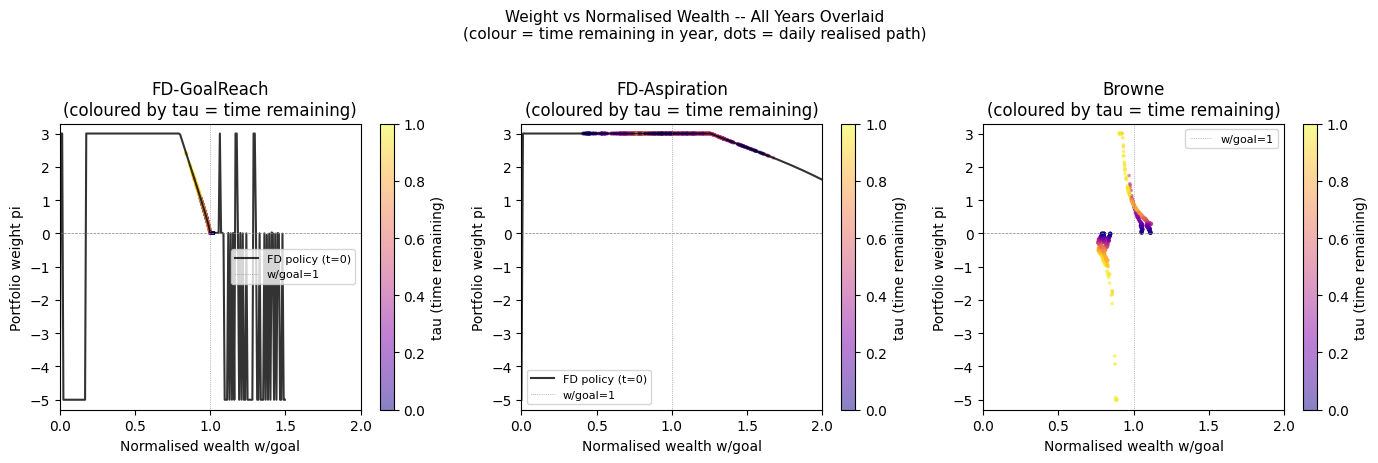

In [10]:
# Focus on a single year and show pi vs w/goal scatter
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

for ax_col, (label, res, color) in enumerate([
        ('FD-GoalReach',  res_fd_gr,  'red'),
        ('FD-Aspiration', res_fd_as,  'darkred'),
        ('Browne',        res_browne, 'blue'),
]):
    ax = axes[ax_col]
    all_w_norm = []
    all_pi     = []
    all_tau    = []
    CMAP_COLORS= plt.cm.viridis(np.linspace(0,1,N_YEARS))

    for yr in range(N_YEARS):
        seg_start = yr*DAYS_PER_YEAR
        seg_end   = (yr+1)*DAYS_PER_YEAR
        W_seg  = res['W'][seg_start:seg_end]
        pi_seg = res['pi'][seg_start:seg_end]
        goal   = res['goals'][yr]
        w_norm = W_seg / goal
        tau_arr = np.linspace(1.0, 1/DAYS_PER_YEAR, DAYS_PER_YEAR)

        sc = ax.scatter(w_norm, pi_seg, c=tau_arr, cmap='plasma',
                        s=3, alpha=0.5, vmin=0, vmax=1)

    # Overlay the static FD policy curve
    if label == 'FD-GoalReach':
        mask = w_gr <= 1.5
        ax.plot(w_gr[mask], Pi_gr[mask], 'k-', lw=1.5, label='FD policy (t=0)', alpha=0.8)
    elif label == 'FD-Aspiration':
        mask = w_as <= 2.0
        ax.plot(w_as[mask], Pi_as[mask], 'k-', lw=1.5, label='FD policy (t=0)', alpha=0.8)

    ax.axhline(0, c='gray', lw=0.5, ls='--')
    ax.axvline(1.0, c='gray', lw=0.5, ls=':', label='w/goal=1')
    ax.set_xlabel('Normalised wealth w/goal')
    ax.set_ylabel('Portfolio weight pi')
    ax.set_title(f'{label}\n(coloured by tau = time remaining)')
    ax.set_xlim(0, 2.0); ax.set_ylim(D_CONST-0.3, U_CONST+0.3)
    ax.legend(fontsize=8)
    plt.colorbar(sc, ax=ax, label='tau (time remaining)')

plt.suptitle('Weight vs Normalised Wealth -- All Years Overlaid\n'
             '(colour = time remaining in year, dots = daily realised path)',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

## 10. Goal Achievement & Risk Analysis

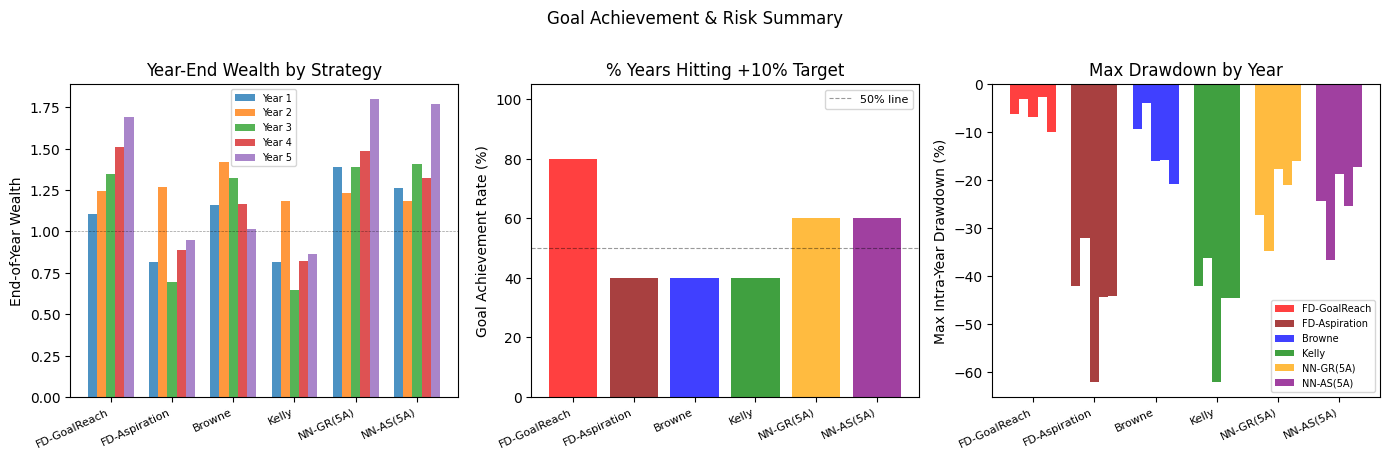


=== Multi-Year Rolling Optimisation Summary ===
Strategy              Total W  Goals   Avg pi   Avg DD
------------------------------------------------------------
FD-GoalReach            1.693    4/5    0.382    -5.71%
FD-Aspiration           0.947    2/5    2.965   -44.88%
Browne                  1.016    2/5    0.022   -13.10%
Kelly                   0.865    2/5    3.000   -45.87%
NN-GR(5A)               1.799    3/5    0.739   -23.27%
NN-AS(5A)               1.770    3/5    0.526   -24.46%


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

all_results = [
    ('FD-GoalReach',  res_fd_gr,  'red'),
    ('FD-Aspiration', res_fd_as,  'darkred'),
    ('Browne',        res_browne, 'blue'),
    ('Kelly',         res_kelly,  'green'),
]
if HAS_NN:
    all_results += [
        ('NN-GR(5A)',  res_nn_gr,  'orange'),
        ('NN-AS(5A)',  res_nn_as,  'purple'),
    ]

labels_r = [r[0] for r in all_results]
x_pos = np.arange(len(labels_r))

# (a) Year-end wealth bar chart
ax = axes[0]
width = 0.15
for yr in range(N_YEARS):
    vals = [r[1]['year_end_W'][yr] for r in all_results]
    ax.bar(x_pos + yr*width, vals, width, label=f'Year {yr+1}', alpha=0.8)
ax.axhline(1.0, c='k', lw=0.5, ls='--', alpha=0.4)
ax.set_xticks(x_pos + (N_YEARS-1)*width/2); ax.set_xticklabels(labels_r, rotation=25, ha='right', fontsize=8)
ax.set_ylabel('End-of-Year Wealth'); ax.set_title('Year-End Wealth by Strategy')
ax.legend(fontsize=7)

# (b) Goal achievement rate
ax = axes[1]
goal_rates = [r[1]['goal_hit'].mean()*100 for r in all_results]
bar_colors = [r[2] for r in all_results]
ax.bar(x_pos, goal_rates, color=bar_colors, alpha=0.75)
ax.axhline(50, c='k', lw=0.8, ls='--', alpha=0.4, label='50% line')
ax.set_xticks(x_pos); ax.set_xticklabels(labels_r, rotation=25, ha='right', fontsize=8)
ax.set_ylabel('Goal Achievement Rate (%)'); ax.set_title(f'% Years Hitting +{(ANNUAL_TARGET-1)*100:.0f}% Target')
ax.set_ylim(0, 105); ax.legend(fontsize=8)

# (c) Max intra-year drawdown
ax = axes[2]
for i, (label, res, color) in enumerate(all_results):
    W = res['W']
    max_dds = []
    for yr in range(N_YEARS):
        seg = W[yr*DAYS_PER_YEAR:(yr+1)*DAYS_PER_YEAR+1]
        peak = np.maximum.accumulate(seg)
        dd   = ((seg - peak) / (peak+1e-8)).min() * 100
        max_dds.append(dd)
    ax.bar(i + np.arange(N_YEARS)*0.15 - (N_YEARS-1)*0.075, max_dds,
           width=0.15, label=label, color=color, alpha=0.75)

ax.set_xticks(x_pos); ax.set_xticklabels(labels_r, rotation=25, ha='right', fontsize=8)
ax.set_ylabel('Max Intra-Year Drawdown (%)')
ax.set_title('Max Drawdown by Year')
ax.legend(fontsize=7)

plt.suptitle('Goal Achievement & Risk Summary', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

# ── Text summary ─────────────────────────────────────────────────────────
print("\n=== Multi-Year Rolling Optimisation Summary ===")
print(f"{'Strategy':<20} {'Total W':>8} {'Goals':>6} {'Avg pi':>8} {'Avg DD':>8}")
print('-'*60)
for label, res, _ in all_results:
    total_w = res['W'][-1]
    goals_hit = f"{res['goal_hit'].sum()}/{N_YEARS}"
    if res['pi'].ndim == 1:
        avg_pi = res['pi'].mean()
    else:
        avg_pi = res['pi'].sum(1).mean()   # sum of weights per day
    # avg drawdown
    dds = []
    for yr in range(N_YEARS):
        seg = res['W'][yr*DAYS_PER_YEAR:(yr+1)*DAYS_PER_YEAR+1]
        peak = np.maximum.accumulate(seg)
        dds.append(((seg-peak)/(peak+1e-8)).min()*100)
    print(f"{label:<20} {total_w:>8.3f} {goals_hit:>6} {avg_pi:>8.3f} {np.mean(dds):>8.2f}%")